In [3]:
import jax
import jax.numpy as jnp
from flax import linen as nn
from flax.training import train_state
import optax
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
from functools import partial
import scipy.io
from sklearn.model_selection import train_test_split
import time
import pickle
import random
import torch
import itertools
from scipy.interpolate import griddata
import scipy
import os
from scipy.stats import pearsonr
import matplotlib.ticker as mticker

In [4]:
from models_fno import FNO1d
from utils_jax import save_model_params, load_model_params
from utils_jax import dataloader

In [ ]:
dataset = scipy.io.loadmat("/home/dnayak2/data_sgoswam4/Dibya/Datasets/1D_Burgers/Burger.mat")
output = dataset['output']
Ns, Nt, Nx = output.shape
print(f"Ns: {Ns}, Nt: {Nt}, Nx: {Nx}")


tt = int(Nt//2)

#Creating the input and output training data
init_timestep = 0
end_timestep = tt

input_data_NN = output[:,init_timestep,:]
output_data_NN = output[:,init_timestep+1,:]

for i in range(init_timestep+1, end_timestep):
    input_data_NN = jnp.vstack((input_data_NN, output[:,i,:]))
    output_data_NN = jnp.vstack((output_data_NN, output[:,i+1,:]))
print(f"Input/Output shapes: {input_data_NN.shape}, {output_data_NN.shape}")

#Create the mesh
mesh = jnp.linspace(0, 1, Nx)
mesh_tensor_repeated = jnp.tile(mesh[None, None, :], (input_data_NN.shape[0], 1, 1))
print(mesh_tensor_repeated.shape)

#Concatenate to original input-output solution fields
input_data_NN_mod = jnp.concatenate([input_data_NN[:,None,:], mesh_tensor_repeated], axis=1)
output_data_NN_mod = output_data_NN[:,None,:]
print(input_data_NN_mod.shape, output_data_NN_mod.shape)

#Free up some memory
del input_data_NN, output_data_NN, mesh_tensor_repeated


Ns: 2500, Nt: 101, Nx: 101
Input/Output shapes: (125000, 101), (125000, 101)
(125000, 1, 101)
(125000, 2, 101) (125000, 1, 101)


In [ ]:
#Separate into train and test datasets
Ntrain = int(0.8*Ns)
perm = jax.random.permutation(jax.random.PRNGKey(0), Ns)

train_idx = perm[:Ntrain]
test_idx = perm[Ntrain:]

train_x = jnp.take(input_data_NN_mod, train_idx, axis=0)
test_x = jnp.take(input_data_NN_mod, test_idx, axis=0)

train_y = jnp.take(output_data_NN_mod, train_idx, axis=0)
test_y = jnp.take(output_data_NN_mod, test_idx, axis=0)

print(f"train_x shape: {train_x.shape}, train_y shape: {train_y.shape}")
print(f"test_x shape: {test_x.shape}, test_y shape: {test_y.shape}")


train_x shape: (2000, 2, 101), train_y shape: (2000, 1, 101)
test_x shape: (500, 2, 101), test_y shape: (500, 1, 101)


In [ ]:
train_x.shape

(2000, 2, 101)

In [ ]:
#Create the FNO-1D model object
modes = 24
fno = FNO1d(in_channels = 2,
            out_channels = 1,
            modes = modes,
            width = 64,
            activation = nn.activation.gelu,
            n_blocks = 6
)
print(f"FNO AR model: {fno}")
model_fn = jax.jit(fno.apply)

FNO AR model: FNO1d(
    # attributes
    in_channels = 2
    out_channels = 1
    modes = 24
    width = 64
    n_blocks = 6
    activation = gelu
)


In [9]:
#Instantiate the model params
# seed = 42
seed = np.random.choice(np.arange(99999), size=1, replace=True)[0]
print(f"Seed: {seed}")
params = fno.init(jax.random.PRNGKey(seed), train_x[0:1])
total_params = sum(x.size for x in jax.tree_util.tree_leaves(params))
print(f"Total parameters: {total_params:,}")
@jax.jit
def loss_fn(params, x, y):
    y_pred = model_fn(params, x)
    # y_pred = RK4(params,x)
    loss = jnp.mean((y_pred - y) ** 2)
    return loss

@jax.jit
def make_step(params, opt_state, x, y):
    loss, grads = jax.value_and_grad(loss_fn)(params, x, y)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

def create_input(x):
    mesh = jnp.linspace(0, 1, Nx)
    mesh_tensor_repeated = jnp.tile(mesh[None, None, :], (x.shape[0], 1, 1))
    x_with_mesh = jnp.concatenate([x[:,None,:], mesh_tensor_repeated], axis=1)
    return x_with_mesh    #(Ns, Nc=2, Nx)

# 4th order Runge-Kutta method
@jax.jit
def RK4(params,x):
    dt = 0.01
    # curr_state = x
    print(x.shape)
    k1 = model_fn(params,x)
    k1 = create_input(k1[:,0,:])
    # k1 = k1.reshape(k1.shape[0],nx,ny)
    k2 = model_fn(params,x+0.5*dt*k1)
    k2 = create_input(k2[:,0,:])
    # k2 = k2.reshape(k2.shape[0],nx,ny)
    k3 = model_fn(params,x+0.5*dt*k2)
    k3 = create_input(k3[:,0,:])
    # k3 = k3.reshape(k3.shape[0],nx,ny)
    k4 = model_fn(params,x+dt*k3)
    k4 = create_input(k4[:,0,:])
    # k4 = k4_fn(k4.shape[0],nx,ny)
    next_state = x+(dt/6)*(k1+2*k2+2*k3+k4)
    next_state = next_state[:,0,:]
    next_state = next_state[:,jnp.newaxis,:]
    # print(next_state.shape)
    # next_state = next_state.reshape(next_state.shape[0],nx*ny)
    return next_state

lr = 1e-3
lr_scheduler = optax.schedules.exponential_decay(init_value=lr, transition_steps=2000, decay_rate=0.96)
optimizer = optax.adam(lr_scheduler)
opt_state = optimizer.init(params)

Seed: 89404
Total parameters: 1,204,865


In [10]:
from tqdm import tqdm

loss_history = []
val_loss_history = []
# batch_size = 64
batch_size = 256     #Being set only for the computational cost analysis
# shuffle_key = jax.random.PRNGKey(80)
shuffle_key = jax.random.PRNGKey(seed)
epochs = int(5e4)
min_val_loss = jnp.inf

result_dir = "./AR-FNO-params"
filename = f"best_model_params_FNO_AR_1Burgers.pkl"

for epoch in (range(epochs)):
    shuffle_key, subkey = jax.random.split(shuffle_key)
    total_loss = 0
    nbatches = 0

    for batch_x, batch_y in tqdm(dataloader(subkey, train_x, train_y, batch_size)):
                                    # desc=f"Epoch {epoch}", leave=False):
        params, opt_state, loss = make_step(params, opt_state, batch_x, batch_y)
        total_loss += loss
        nbatches += 1

    loss = total_loss / nbatches
    val_loss = loss_fn(params, test_x, test_y)

    if val_loss < min_val_loss:
        best_params = params
        min_val_loss = val_loss
        # save_model_params(best_params, result_dir, filename=filename)

    loss_history.append(loss)
    val_loss_history.append(val_loss)

    if epoch % 500 == 0:
        print(f"Epoch: {epoch}, Train loss: {loss}, Val loss: {val_loss}")


8it [00:05,  1.34it/s]


Epoch: 0, Train loss: 0.025374766439199448, Val loss: 0.007019959390163422


8it [00:00, 263.72it/s]
8it [00:00, 276.50it/s]
8it [00:00, 295.81it/s]
8it [00:00, 297.45it/s]
8it [00:00, 294.72it/s]
8it [00:00, 298.14it/s]
8it [00:00, 297.56it/s]
8it [00:00, 298.84it/s]
8it [00:00, 297.08it/s]
8it [00:00, 298.17it/s]
8it [00:00, 298.00it/s]
8it [00:00, 298.62it/s]
8it [00:00, 298.26it/s]
8it [00:00, 295.33it/s]
8it [00:00, 296.78it/s]
8it [00:00, 297.53it/s]
8it [00:00, 296.64it/s]
8it [00:00, 293.54it/s]
8it [00:00, 296.36it/s]
8it [00:00, 297.65it/s]
8it [00:00, 298.95it/s]
8it [00:00, 296.88it/s]
8it [00:00, 299.12it/s]
8it [00:00, 296.79it/s]
8it [00:00, 297.02it/s]
8it [00:00, 297.90it/s]
8it [00:00, 297.08it/s]
8it [00:00, 296.34it/s]
8it [00:00, 297.33it/s]
8it [00:00, 295.71it/s]
8it [00:00, 296.78it/s]
8it [00:00, 297.42it/s]
8it [00:00, 296.19it/s]
8it [00:00, 296.99it/s]
8it [00:00, 295.21it/s]
8it [00:00, 296.91it/s]
8it [00:00, 294.71it/s]
8it [00:00, 297.52it/s]
8it [00:00, 297.02it/s]
8it [00:00, 296.70it/s]
8it [00:00, 297.12it/s]
8it [00:00, 296.

KeyboardInterrupt: 

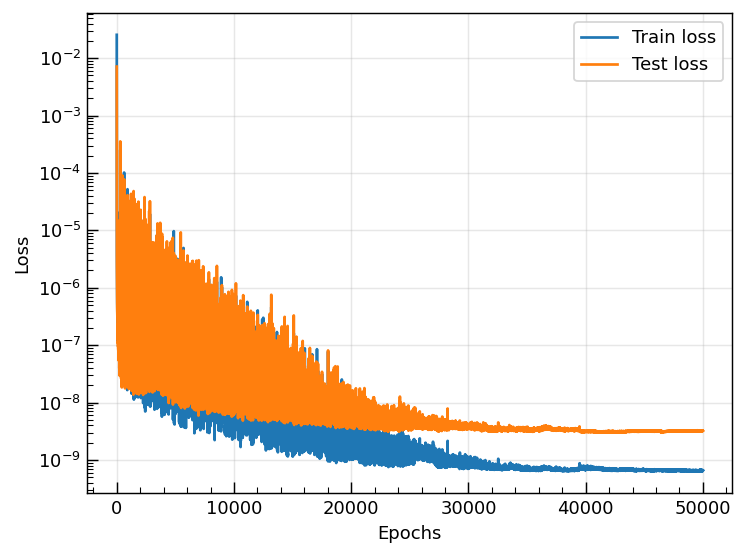

In [9]:
plt.figure(dpi = 130)
plt.semilogy(np.arange(epoch+1), loss_history, label = "Train loss")
plt.semilogy(np.arange(epoch+1), val_loss_history, label = "Test loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.tick_params(which = 'major', axis = 'both', direction = 'in', length = 6)
plt.tick_params(which = 'minor', axis = 'both', direction = 'in', length = 3.5)
plt.minorticks_on()

plt.grid(alpha = 0.3)
plt.legend(loc = 'best')
# plt.savefig(result_dir + f"/loss_plot_{modes1}.jpeg", dpi = 800)
plt.show()

In [10]:
best_params = load_model_params(result_dir, filename = filename)

In [11]:
def create_input(x):
    mesh = jnp.linspace(0, 1, Nx)
    mesh_tensor_repeated = jnp.tile(mesh[None, None, :], (x.shape[0], 1, 1))
    x_with_mesh = jnp.concatenate([x[:,None,:], mesh_tensor_repeated], axis=1)
    return x_with_mesh    #(Ns, Nc=2, Nx)


def run_inference(initial_u, n_steps):
    u_states = np.zeros_like(output)  # List to store the states over time
    u_states[:,0,:] = initial_u
    
    # Initialize the previous state (this could be your u_0 and u_1, etc.)
    u_curr = initial_u  # Set the current state to the initial state
    
    for i in range(1, n_steps):
        
        u_curr_in_FNO = create_input(u_curr) #(Ns, in_channels, Nx)
        # print(i,u_curr_in_FNO.shape)
        # u_next_out_FNO = RK4(best_params, u_curr_in_FNO) #(Ns, out_channels, Nx)
        u_next_out_FNO = model_fn(best_params, u_curr_in_FNO) #(Ns, out_channels, Nx)
        # print(u_next_out_FNO.shape)
        u_next = u_next_out_FNO[:,0,:]
        
        # Append the predicted state to the list
        u_states[:,i,:] = u_next
        
        # Update previous and current states for the next step
        u_curr = u_next
    
    return u_states



In [12]:
u_curr = output[:, 0, :]

start_time = time.time()
u_pred = run_inference(u_curr, n_steps=Nt)
end_time = time.time()
print(f"Total inferencing time for {u_pred.shape[0]} samples: {end_time-start_time}")

print(f"u_pred: {u_pred.shape}, outputs: {output.shape}")
overall_rel_l2_err = jnp.linalg.norm(u_pred - output)/jnp.linalg.norm(output)
print(f"Overall relative L2 error: {overall_rel_l2_err}")

#Find the autoregressive errors

auto_reg_error = []

for i in range(Nt):
    err = np.linalg.norm(u_pred[:,i,:] - output[:,i,:])/np.linalg.norm(output[:,i,:])
    auto_reg_error.append(err)

Total inferencing time for 2500 samples: 2.331650495529175
u_pred: (2500, 101, 101), outputs: (2500, 101, 101)
Overall relative L2 error: 0.11759920418262482
